In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
dataset=pd.read_csv("Churn_Modelling.csv")
x=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]
x.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [2]:
geo=pd.get_dummies(x["Geography"],drop_first=True)
gen=pd.get_dummies(x["Gender"],drop_first=True)
x=x.drop(["Geography","Gender"],axis=1)
x=pd.concat([x,geo,gen],axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout
classifier=Sequential()
classifier.add(Dense(units=11, activation='relu'))
classifier.add(Dense(units=7, activation='relu'))
classifier.add(Dense(units=6, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))

In [5]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7962 - loss: 0.5022 - val_accuracy: 0.7955 - val_loss: 0.4786
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.4528 - val_accuracy: 0.7955 - val_loss: 0.4480
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7962 - loss: 0.4240 - val_accuracy: 0.7955 - val_loss: 0.4286
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7979 - loss: 0.4069 - val_accuracy: 0.8035 - val_loss: 0.4181
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8110 - loss: 0.3966 - val_accuracy: 0.8167 - val_loss: 0.4105
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8283 - loss: 0.3886 - val_accuracy: 0.8213 - val_loss: 0.4031
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8365 - loss: 0.3811 - val_accuracy: 0.8315 - val_loss: 0.3959
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8429 - loss: 0.3741 - val_accu

In [6]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

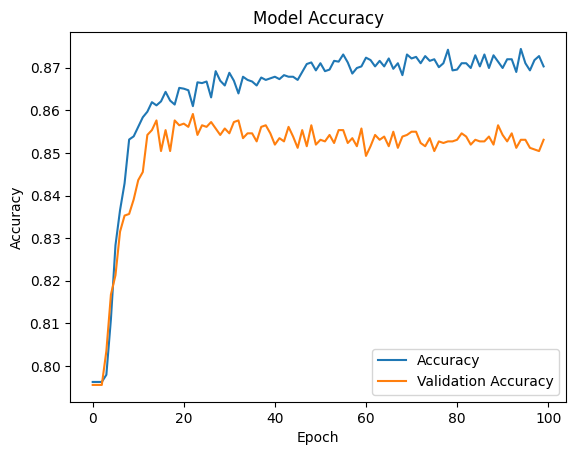

In [7]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","Validation Accuracy"])
plt.show()

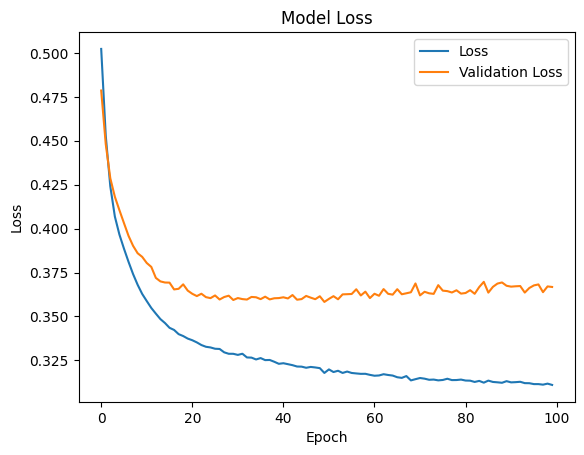

In [8]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Loss","Validation Loss"])
plt.show()

In [9]:
y_pred=classifier.predict(x_test)
y_pred=(y_pred>0.5)
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


array([[1468,  127],
       [ 174,  231]])

In [10]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.8495

In [11]:
classifier.get_weights()

[array([[-2.04385713e-01,  1.56599820e-01,  6.88868284e-01,
         -9.52505246e-02, -4.88921814e-02, -5.07255271e-02,
         -2.35768288e-01,  6.59630716e-01, -1.85026675e-01,
          9.65317637e-02,  1.42797887e-01],
        [-3.25218946e-01, -1.74219057e-01, -8.46468329e-01,
         -6.09216332e-01,  2.98659205e-01,  1.87300533e-01,
         -4.76760060e-01, -6.31588325e-02,  3.79133373e-01,
          9.86904383e-01,  5.24039455e-02],
        [-6.20064914e-01,  2.12293103e-01, -4.45113361e-01,
          2.85058737e-01,  8.31156746e-02,  6.59920201e-02,
         -1.52549054e-02, -8.58286470e-02,  1.30104467e-01,
         -2.30531350e-01, -1.15897320e-01],
        [-8.39098766e-02, -3.74973446e-01,  3.57289523e-01,
          8.68171528e-02,  3.03481314e-02, -5.58848202e-01,
         -9.04280901e-01, -7.78535426e-01, -4.69753265e-01,
          9.81640592e-02,  1.59139372e-02],
        [ 1.25744790e-01, -1.42958626e-01, -7.03755140e-01,
         -1.83091909e-01,  9.26685035e-01, -